In [1]:
!source ./venv_kursach/bin/activate

In [2]:
#Наш env
from BatteryEnvironment import BatteryEnv

#Наш Q-learning
from QLearningClass import QLearningAgent

#Базовые библиотеки
import numpy as np
import matplotlib.pyplot as plt

## Тестовый запуск 

In [3]:
env = BatteryEnv()
obs, info = env.reset()
print(f"Первое состояние (должно быть 6 чисел): {obs}")
print(f"Размерность observation_space: {env.observation_space.shape}")

Первое состояние (должно быть 6 чисел): [0.5 1.  1.  0.  2.  0. ]
Размерность observation_space: (6,)


## Rule Based

In [4]:
def rule_based_policy(obs):
    hour = obs[5]
    if hour <= 6: return [1.0]  # Заряжаем ночью по полной
    if 18 <= hour <= 22: return [-1.0] # Разряжаем в пик
    return [0.0] # В остальное время отдыхаем

In [5]:
# Запуск цикла
obs, info = env.reset()
total_reward = 0
done = False
history = []

while not done:
    action = rule_based_policy(obs)
    next_obs, reward, terminated, truncated, info = env.step(action)

    history.append({
        'hour': obs[5],
        'soc': obs[0],
        'price': obs[4],
        'reward': reward
    })

    obs = next_obs
    total_reward += reward
    done = terminated or truncated

print(f"Итоговый Reward за сутки (Rule-Based): {total_reward:.2f}")  

Итоговый Reward за сутки (Rule-Based): -109.90


## Q-Learning ##

In [6]:
def discretize_state(obs):
    # obs = [soc, soh, load, pv, price, hour]
    soc = int(obs[0] * 10)     # 0.54 -> 5 (разбили на 10 корзин)
    hour = int(obs[5])         # уже целое от 0 до 23
    
    # Для начала ограничимся только SoC и Hour, чтобы таблица не раздулась. 
    # Этого достаточно, так как цена и нагрузка у нас зависят от часа.
    return (soc, hour)

In [7]:
agent = QLearningAgent()
episodes = 2000
rewards_history = []

for e in range(episodes):
    obs, _ = env.reset()
    state = discretize_state(obs)
    total_reward = 0
    done = False

    while not done:
        action_idx = agent.get_action(state)

        real_action = [float(action_idx - 1)]
        next_obs, reward, terminated, truncated, _ = env.step(real_action)
        next_state = discretize_state(next_obs)

        agent.learn(state, action_idx, reward, next_state)

        state = next_state
        total_reward += reward
        done = terminated or truncated

    agent.epsilon = max(agent.min_epsilon, agent.epsilon * agent.epsilon_decay)
    rewards_history.append(total_reward)

    if (e + 1) % 500 == 0:
        print(f"Эпизод {e+1}, Средняя награда: {np.mean(rewards_history[-100:]):.2f}, Epsilon: {agent.epsilon:.2f}")

Эпизод 500, Средняя награда: -62.07, Epsilon: 0.08
Эпизод 1000, Средняя награда: -47.03, Epsilon: 0.01
Эпизод 1500, Средняя награда: -36.79, Epsilon: 0.01
Эпизод 2000, Средняя награда: -35.99, Epsilon: 0.01


## Визуализация

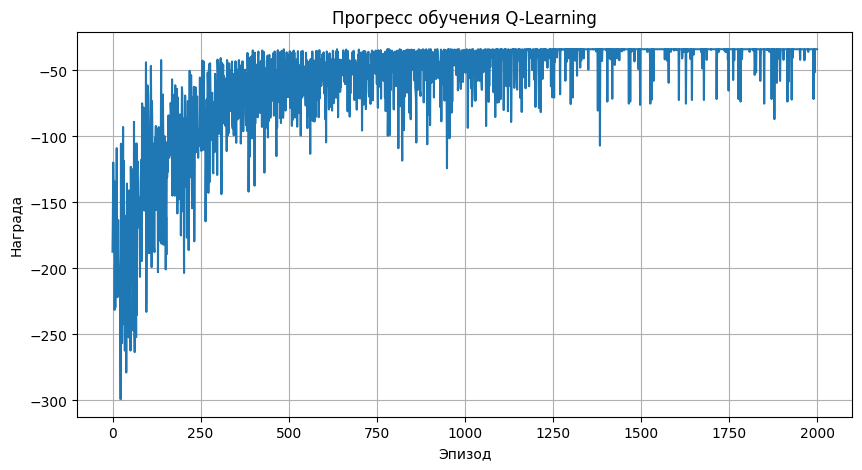

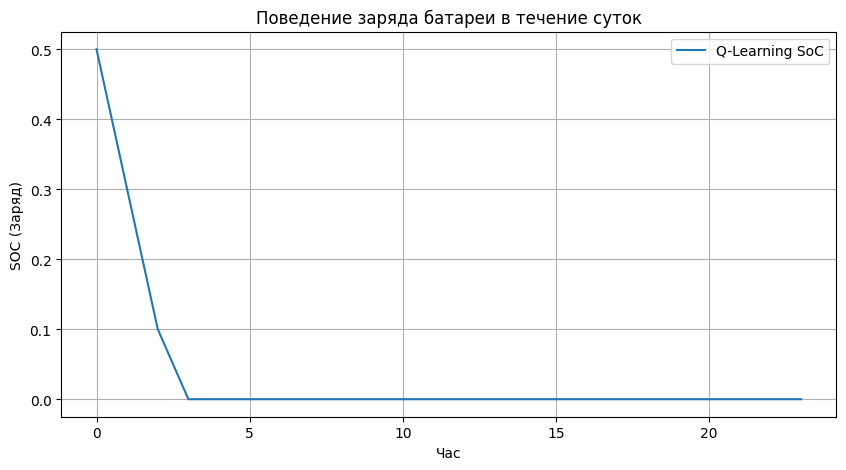

In [8]:
# 1. График обучения
plt.figure(figsize=(10, 5))
plt.plot(rewards_history)
plt.title('Прогресс обучения Q-Learning')
plt.xlabel('Эпизод')
plt.ylabel('Награда')
plt.grid(True)
plt.show()

# 2. Сравнение стратегий на одних сутках
obs, _ = env.reset()
done = False
q_socs = []
hours = []

while not done:
    state = discretize_state(obs)
    action_idx = agent.get_action(state, explore=False) # Берем только лучшее
    real_action = [float(action_idx - 1)]
    
    q_socs.append(obs[0])
    hours.append(obs[5])
    
    obs, _, terminated, truncated, _ = env.step(real_action)
    done = terminated or truncated

plt.figure(figsize=(10, 5))
plt.plot(hours, q_socs, label='Q-Learning SoC')
# Тут можно добавить SoC от Rule-based для сравнения
plt.title('Поведение заряда батареи в течение суток')
plt.xlabel('Час')
plt.ylabel('SOC (Заряд)')
plt.legend()
plt.grid(True)
plt.show()

## Сравнение

Сброс среды

In [9]:
obs_q, _ = env.reset()
obs_rb, _ = env.reset() 

q_socs, rb_socs, hours = [], [], []
done_q, done_rb = False, False

Прогон Q-learning

In [10]:
while not done_q:
    state = discretize_state(obs_q)
    action_idx = agent.get_action(state, explore=False)
    real_action = [float(action_idx - 1)]
    q_socs.append(obs_q[0])
    hours.append(obs_q[5])
    obs_q, _, terminated, truncated, _ = env.step(real_action)
    done_q = terminated or truncated

Прогон Rule-based

In [11]:
env.reset()
obs_rb, _ = env.reset()
while not done_rb:
    action = rule_based_policy(obs_rb)
    rb_socs.append(obs_rb[0])
    obs_rb, _, terminated, truncated, _ = env.step(action)
    done_rb = terminated or truncated

Визуализация

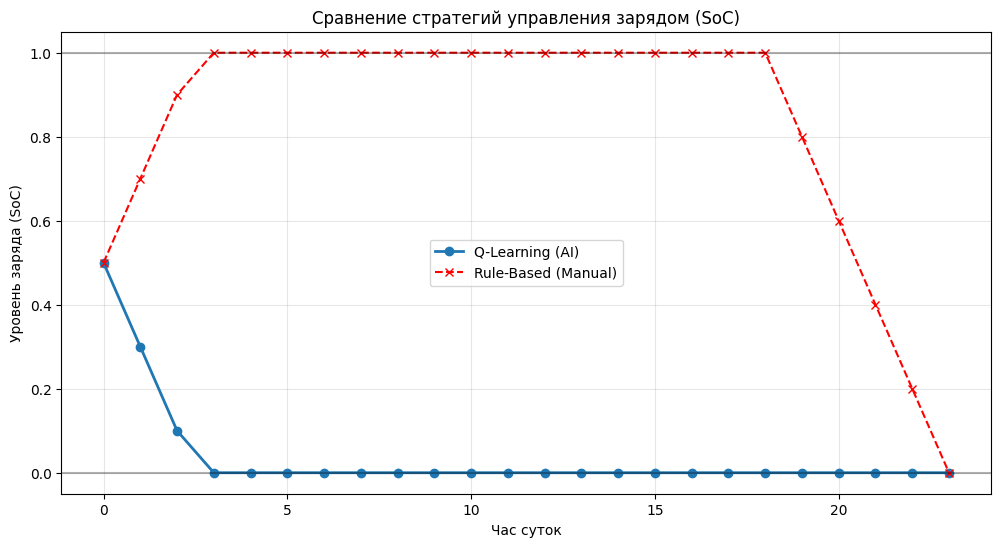

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(hours, q_socs, label='Q-Learning (AI)', linewidth=2, marker='o')
plt.plot(hours, rb_socs, label='Rule-Based (Manual)', linestyle='--', color='red', marker='x')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.axhline(y=1, color='black', linestyle='-', alpha=0.3)

plt.title('Сравнение стратегий управления зарядом (SoC)')
plt.xlabel('Час суток')
plt.ylabel('Уровень заряда (SoC)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Сохранение

In [13]:
# Сохранение обученной таблицы
def save_agent(agent, filename="q_table_battery.npy"):
    np.save(filename, agent.q_table)
    print(f"Модель сохранена в файл {filename}")

# Загрузка таблицы в агента
def load_agent(agent, filename="q_table_battery.npy"):
    try:
        agent.q_table = np.load(filename)
        agent.epsilon = agent.min_epsilon # Отключаем исследование при загрузке готовой модели
        print(f"Модель успешно загружена из {filename}")
    except FileNotFoundError:
        print("Файл не найден. Начните обучение с нуля.")

In [17]:
save_agent(agent)
# load_agent(agent)

Модель сохранена в файл q_table_battery.npy


## Эксперимент

Эксперимент №2: Оптимизация стратегии и анализ влияния штрафа за износ (SoH)
Цель: Выяснить, почему агент выбирает пассивную стратегию (удержание нулевого заряда), и адаптировать вознаграждение для более активного участия в балансировке сети.

Гипотеза: Текущий штраф за износ батареи в функции reward перевешивает потенциальную выгоду от арбитража электроэнергии. Снизив коэффициент износа или увеличив стоимость пиковой энергии, мы должны увидеть более активные циклы заряда/разряда.

Было:
reward = -cost - (abs(energy_change) * 10.0)

Стало (более агрессивная стратегия):
reward = -cost - (abs(energy_change) * 2.0)

In [18]:
# 1. Переинициализируем среду (чтобы подтянулись изменения из файла)
import importlib
import BatteryEnvironment
importlib.reload(BatteryEnvironment)
from BatteryEnvironment import BatteryEnv

In [19]:
env = BatteryEnv()
agent = QLearningAgent() 

# 2. Обучение (2000 эпизодов хватит)
episodes = 2000
for e in range(episodes):
    obs, _ = env.reset()
    state = discretize_state(obs)
    done = False
    while not done:
        action_idx = agent.get_action(state)
        real_action = [float(action_idx - 1)]
        next_obs, reward, terminated, truncated, _ = env.step(real_action)
        agent.learn(state, action_idx, reward, discretize_state(next_obs))
        state = discretize_state(next_obs)
        done = terminated or truncated
    agent.epsilon = max(agent.min_epsilon, agent.epsilon * agent.epsilon_decay)

# 3. Финальный тест с визуализацией баланса
obs, _ = env.reset()
history = {'soc': [], 'price': [], 'grid': [], 'hours': []}
done = False

while not done:
    state = discretize_state(obs)
    action_idx = agent.get_action(state, explore=False)
    real_action = [float(action_idx - 1)]
    
    # Сохраняем данные до шага
    history['soc'].append(obs[0])
    history['price'].append(obs[4])
    history['hours'].append(obs[5])
    
    obs, reward, terminated, truncated, _ = env.step(real_action)
    
    # Считаем grid_flow (load - pv + action) для визуализации
    # Берем значения из obs (load - индекс 2, pv - индекс 3)
    grid = obs[2] - obs[3] + (real_action[0] * 2.0) 
    history['grid'].append(grid)
    
    done = terminated or truncated

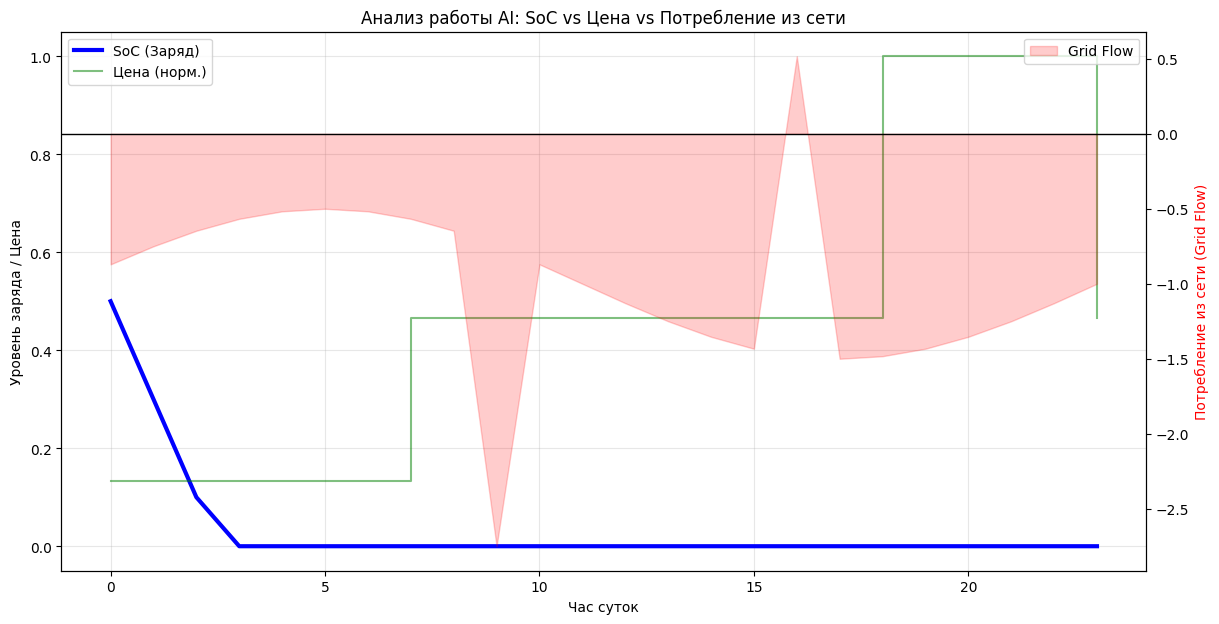

In [ ]:
# ГРАФИК
fig, ax1 = plt.subplots(figsize=(14, 7))

# Ось для SoC и Цены
ax1.set_xlabel('Час суток')
ax1.set_ylabel('Уровень заряда / Цена', color='black')
ax1.plot(history['hours'], history['soc'], label='SoC (Заряд)', color='blue', linewidth=3)
ax1.step(history['hours'], np.array(history['price'])/15, label='Цена (норм.)', color='green', alpha=0.5, where='post')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Вторая ось для Grid Flow (потока из сети)
ax2 = ax1.twinx()
ax2.set_ylabel('Потребление из сети (Grid Flow)', color='red')
ax2.fill_between(history['hours' actions = [[0.0]*8 + [llm_decision] for _ in range(len(env.buildings))]], history['grid'], 0, color='red', alpha=0.2, label='Grid Flow')
ax2.axhline(0, color='black', linewidth=1)
ax2.legend(loc='upper right')

plt.title('Анализ работы AI: SoC vs Цена vs Потребление из сети')
plt.show()